In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/AML_LAB/credit_risk_assessment_500_samples.csv")
df

,Applicant_ID,Age,Annual_Income,Employment_Years,Credit_Score,Loan_Amount,Loan_Term_Months,Existing_Loans_Count,Debt_to_Income_Ratio,Late_Payments_Last_2Yrs,Credit_Risk
0,1,59,153267,28,818,196649,12,2,0.68,0,High
1,2,49,232745,0,436,175354,60,0,0.23,5,High
2,3,35,974945,19,797,662297,48,3,0.54,0,Medium
3,4,63,307164,29,776,831725,48,0,0.56,4,High
4,5,28,685626,6,893,498625,60,3,0.66,8,High
...,...,...,...,...,...,...,...,...,...,...,...
495,496,46,495266,21,385,204363,24,2,0.20,9,High
496,497,30,630703,25,474,615856,36,2,0.21,2,High
497,498,46,1124323,6,492,671827,36,2,0.11,2,High
498,499,54,493054,13,610,621139,60,4,0.33,4,Medium


In [4]:
X = df.drop(columns=["Applicant_ID", "Credit_Risk"])
y = df["Credit_Risk"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets.
X_train shape: (400, 9)
X_test shape: (100, 9)
y_train shape: (400,)
y_test shape: (100,)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

Features scaled successfully.
X_train_scaled shape: (400, 9)
X_test_scaled shape: (100, 9)


In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score, precision_score


NB = MultinomialNB()
LR = LogisticRegression(random_state=42, max_iter=2000)
SVM = SVC(random_state=42)
DT = DecisionTreeClassifier(random_state=42)
RF = RandomForestClassifier(random_state=42)

In [8]:
NB.fit(X_train, y_train)

MultinomialNB()

In [9]:
LR.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000, random_state=42)

In [10]:
SVM.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [11]:
DT.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [12]:
RF.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
y_pred_nb = NB.predict(X_test)
y_pred_lr = LR.predict(X_test_scaled)
y_pred_svm = SVM.predict(X_test_scaled)
y_pred_dt = DT.predict(X_test)
y_pred_rf = RF.predict(X_test)

In [14]:
acc_NB = accuracy_score(y_test, y_pred_nb)
acc_LR = accuracy_score(y_test, y_pred_lr)
acc_SVM = accuracy_score(y_test, y_pred_svm)
acc_DT = accuracy_score(y_test, y_pred_dt)
acc_RF = accuracy_score(y_test, y_pred_rf)

In [15]:
recall_NB = recall_score(y_test, y_pred_nb, average='weighted')
recall_LR = recall_score(y_test, y_pred_lr, average='weighted')
recall_SVM = recall_score(y_test, y_pred_svm, average='weighted')
recall_DT = recall_score(y_test, y_pred_dt, average='weighted')
recall_RF = recall_score(y_test, y_pred_rf, average='weighted')

In [16]:
precision_score_NB = precision_score(y_test, y_pred_nb, average='weighted')
precision_score_LR = precision_score(y_test, y_pred_lr, average='weighted')
precision_score_SVM = precision_score(y_test, y_pred_svm, average='weighted')
precision_score_DT = precision_score(y_test, y_pred_dt, average='weighted')
precision_score_RF = precision_score(y_test, y_pred_rf, average='weighted')

In [17]:
f1_score_NB = f1_score(y_test, y_pred_nb, average='weighted')
f1_score_LR = f1_score(y_test, y_pred_lr, average='weighted')
f1_score_SVM = f1_score(y_test, y_pred_svm, average='weighted')
f1_score_DT = f1_score(y_test, y_pred_dt, average='weighted')
f1_score_RF = f1_score(y_test, y_pred_rf, average='weighted')

In [18]:
Model = ['NB', 'LR', 'SVM', 'DT', 'RF']
Accuracy = [acc_NB, acc_LR, acc_SVM, acc_DT, acc_RF]
Recall = [recall_NB, recall_LR, recall_SVM, recall_DT, recall_RF]
Precision = [precision_score_NB, precision_score_LR, precision_score_SVM, precision_score_DT, precision_score_RF]
F1_Score = [f1_score_NB, f1_score_LR, f1_score_SVM, f1_score_DT, f1_score_RF]

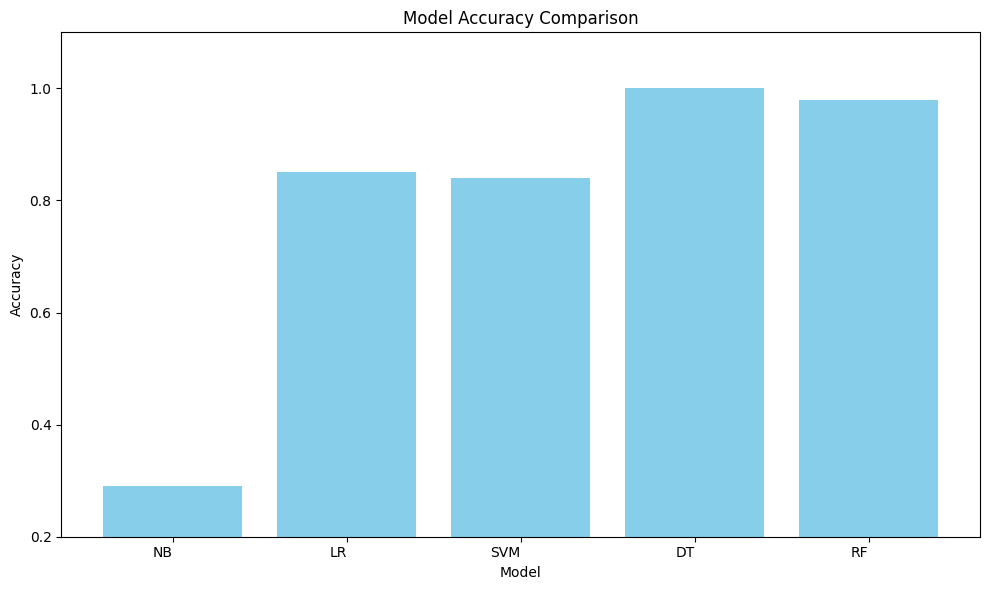

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(Model, Accuracy, color='skyblue')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0.2, 1.1)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

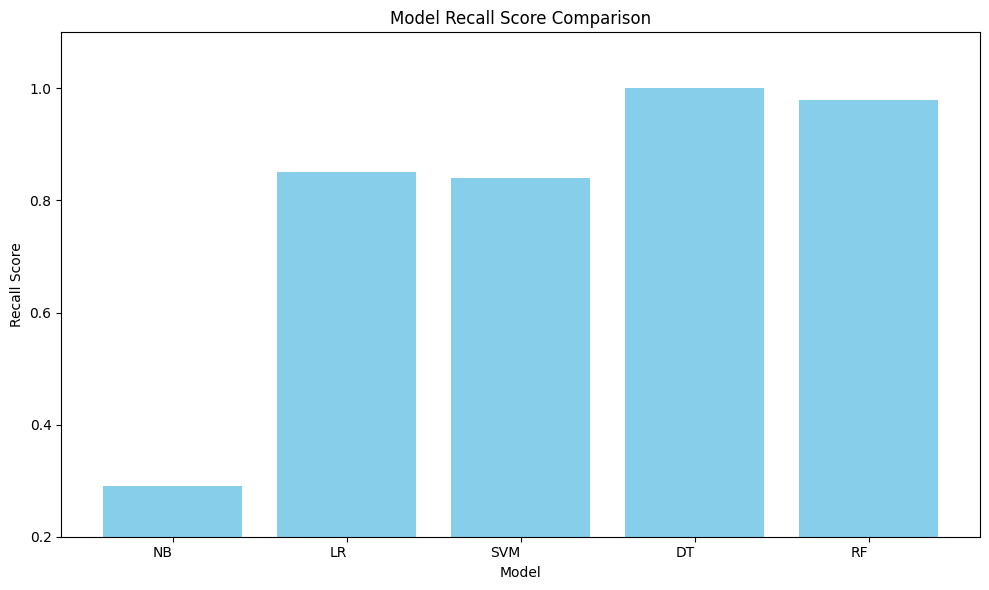

In [20]:
plt.figure(figsize=(10, 6))
plt.bar(Model, Recall, color='skyblue')
plt.title('Model Recall Score Comparison')
plt.ylabel('Recall Score')
plt.xlabel('Model')
plt.ylim(0.2, 1.1)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

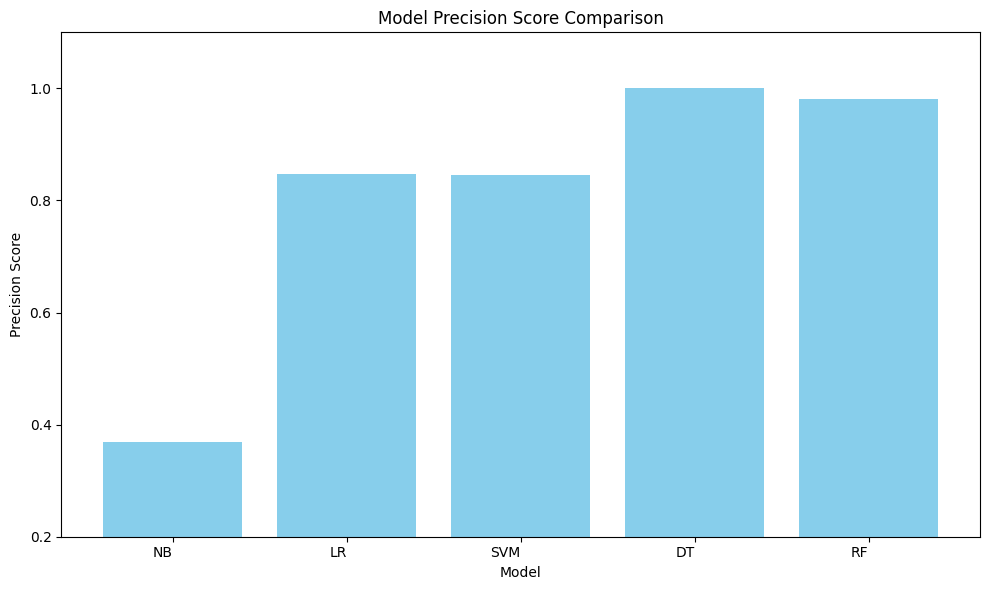

In [21]:
plt.figure(figsize=(10, 6))
plt.bar(Model, Precision, color='skyblue')
plt.title('Model Precision Score Comparison')
plt.ylabel('Precision Score')
plt.xlabel('Model')
plt.ylim(0.2, 1.1)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

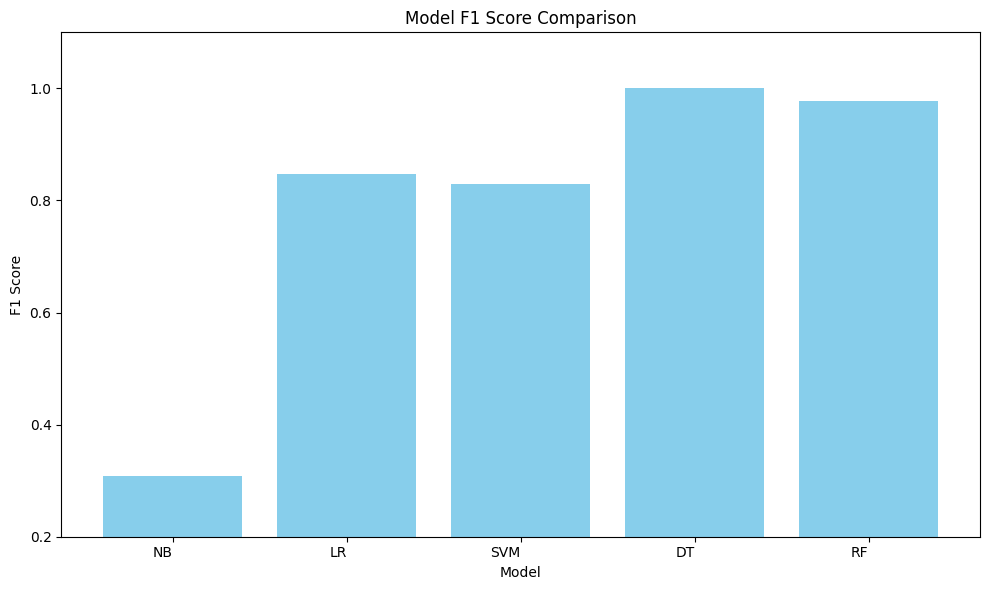

In [22]:
plt.figure(figsize=(10, 6))
plt.bar(Model, F1_Score, color='skyblue')
plt.title('Model F1 Score Comparison')
plt.ylabel('F1 Score')
plt.xlabel('Model')
plt.ylim(0.2, 1.1)
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

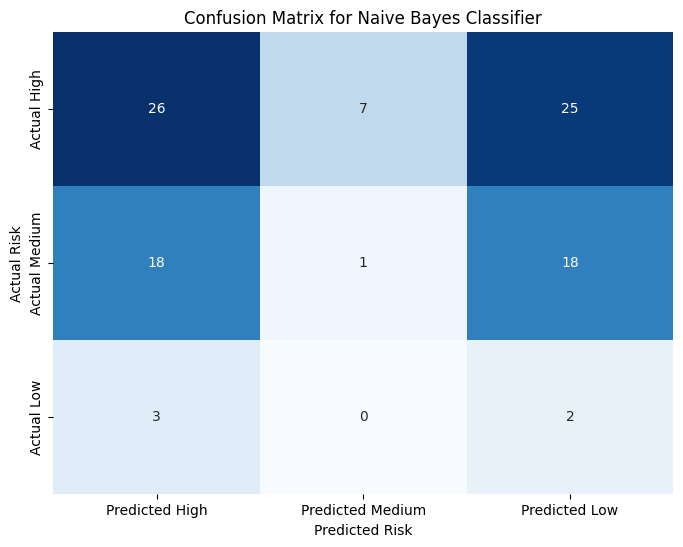

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_nb, labels=['High', 'Medium', 'Low'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted High', 'Predicted Medium', 'Predicted Low'],
            yticklabels=['Actual High', 'Actual Medium', 'Actual Low'])
plt.title('Confusion Matrix for Naive Bayes Classifier')
plt.ylabel('Actual Risk')
plt.xlabel('Predicted Risk')
plt.show()

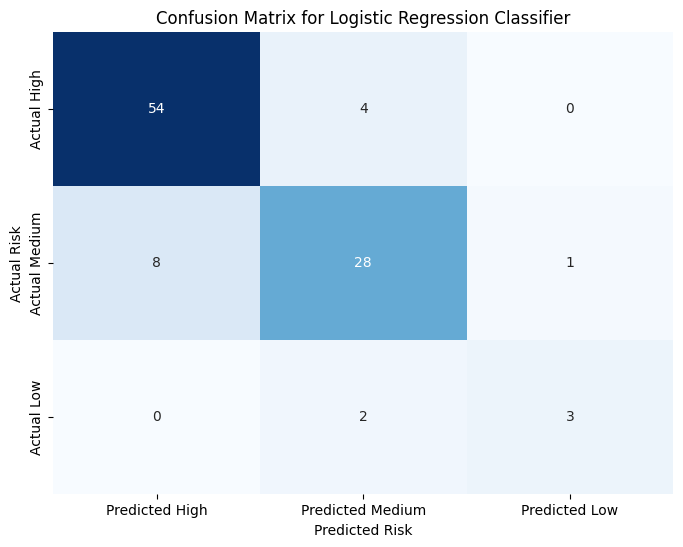

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_lr, labels=['High', 'Medium', 'Low'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted High', 'Predicted Medium', 'Predicted Low'],
            yticklabels=['Actual High', 'Actual Medium', 'Actual Low'])
plt.title('Confusion Matrix for Logistic Regression Classifier')
plt.ylabel('Actual Risk')
plt.xlabel('Predicted Risk')
plt.show()

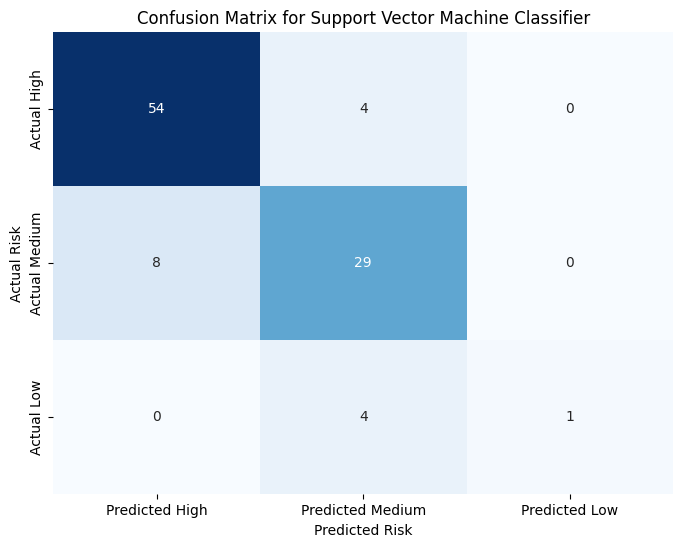

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_svm, labels=['High', 'Medium', 'Low'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted High', 'Predicted Medium', 'Predicted Low'],
            yticklabels=['Actual High', 'Actual Medium', 'Actual Low'])
plt.title('Confusion Matrix for Support Vector Machine Classifier')
plt.ylabel('Actual Risk')
plt.xlabel('Predicted Risk')
plt.show()

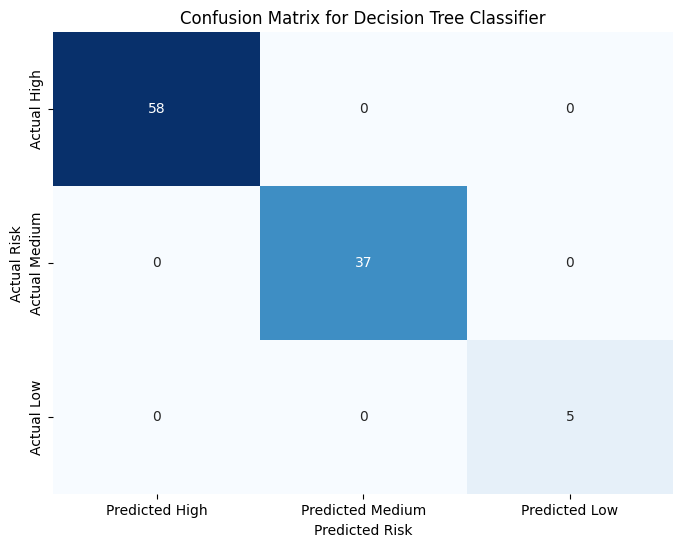

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_dt, labels=['High', 'Medium', 'Low'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted High', 'Predicted Medium', 'Predicted Low'],
            yticklabels=['Actual High', 'Actual Medium', 'Actual Low'])
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.ylabel('Actual Risk')
plt.xlabel('Predicted Risk')
plt.show()

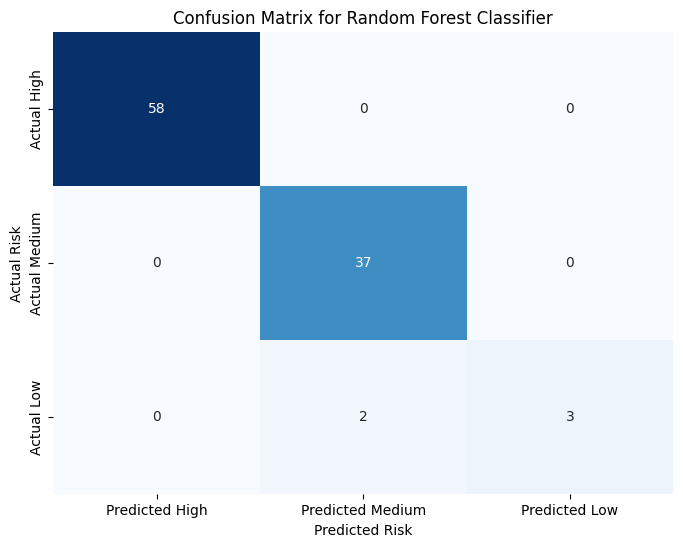

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_rf, labels=['High', 'Medium', 'Low'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted High', 'Predicted Medium', 'Predicted Low'],
            yticklabels=['Actual High', 'Actual Medium', 'Actual Low'])
plt.title('Confusion Matrix for Random Forest Classifier')
plt.ylabel('Actual Risk')
plt.xlabel('Predicted Risk')
plt.show()